In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
warnings.filterwarnings("ignore")

In [6]:
veri = pd.read_csv("age_islenmis.csv")

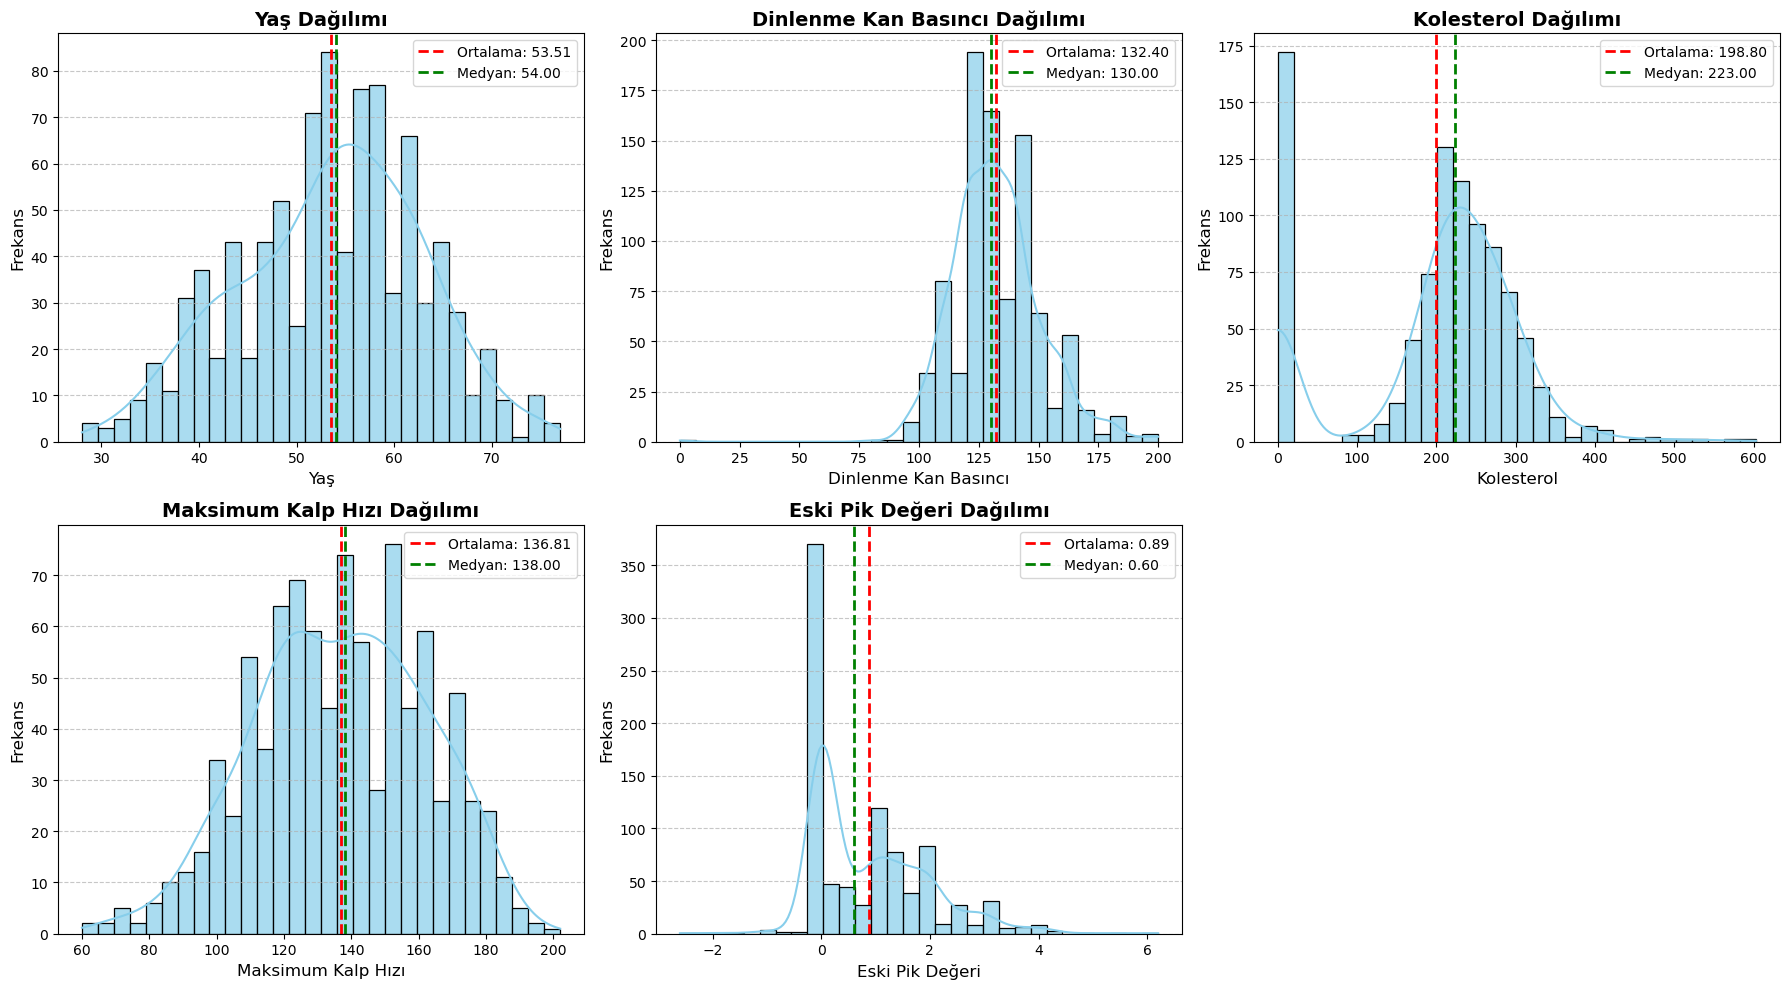

In [7]:
# Numerik sütunların listesi
numerical_columns = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

# Çeviri sözlüğü (Türkçe başlıklar için)
column_translations = {
    'age': 'Yaş',
    'resting bp s': 'Dinlenme Kan Basıncı',
    'cholesterol': 'Kolesterol',
    'max heart rate': 'Maksimum Kalp Hızı',
    'oldpeak': 'Eski Pik Değeri'
}

# Grafikleri 2x3 boyutunda oluştur (2 satır, 3 sütun)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()  # Düz bir diziye dönüştürme

for i, col in enumerate(numerical_columns):
    # Histogram ve Kernel Density Estimate (KDE) grafiği
    sns.histplot(data=veri, x=col, kde=True, bins=30, ax=axes[i], color="skyblue", edgecolor="black", alpha=0.7)
    
    # Ortalama ve medyan değerlerini hesaplama
    mean_val = veri[col].mean()
    median_val = veri[col].median()
    
    # Ortalama ve medyan değerlerini grafiğe ekleme
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Ortalama: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Medyan: {median_val:.2f}')
    
    # Başlık ve etiketler
    axes[i].set_title(f"{column_translations[col]} Dağılımı", fontsize=14, fontweight='bold')
    axes[i].set_xlabel(column_translations[col], fontsize=12)
    axes[i].set_ylabel("Frekans", fontsize=12)
    
    # Legend eklemek
    axes[i].legend(fontsize=10)
    
    # Grid eklemek
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Boş alanları temizleme
if len(numerical_columns) < len(axes):
    for j in range(len(numerical_columns), len(axes)):
        fig.delaxes(axes[j])

# Genel grafik ayarları
plt.tight_layout()
plt.show()

#### **2. Dinlenme Kan Basıncı Dağılımı**

- **Yorum:**
  - Dinlenme kan basıncı dağınık bir dağılıma sahip görünüyor.
  - Ortalama değeri **132.13** , medyan değeri **130.00** .
  - Değerler genellikle **90 ila 180 mmHg aralığında** bulunuyor.
- **Makine Öğrenmesi İçin Gereken Adımlar:**

  1. Ölçeklendirme:
     - Verinin standartlaştırılması için `StandardScaler` veya `RobustScaler` kullanın.
  2. Feature Engineering:
     - Dinlenme kan basıncını kategorik değerlere ayırabilirsiniz (normal, yüksek, çok yüksek).
     - Diğer fizyolojik ölçümlerle birleştirerek yeni özellikler oluşturun (örneğin, `cholesterol / resting_bp_s`).
#### **3. Kolesterol Dağılımı**

- **Yorum:**
  - Kolesterol dağılımı hafifçe sağa çarpık görünüyor.
  - Ortalama değeri **209.91** , medyan değeri **223.00** .
  - Değerler genellikle **50 ila 400 mg/dL aralığında** bulunuyor.
- **Makine Öğrenmesi İçin Gereken Adımlar:**

  1. Ölçeklendirme:
     - `StandardScaler` veya `RobustScaler` kullanarak ölçeklendirin.
  2. Feature Engineering:
     - Kolesterol düzeyini kategorik değerlere ayırabilirsiniz (normal, sınırda, yüksek).
     - Log dönüşümü uygulayarak dağılımı daha normale çekin.

------

#### **4. Maksimum Kalp Hızı Dağılımı**

- **Yorum:**
  - Maksimum kalp hızı dağınık bir dağılıma sahip görünüyor.
  - Ortalama değeri **136.81** , medyan değeri **138.00** .
  - Değerler genellikle **60 ila 200 atım/dakika aralığında** bulunuyor.
- **Makine Öğrenmesi İçin Gereken Adımlar:**
  1. Aykırı Değer Kontrolü:
     - Aykırı değerler tespit edin ve gerekirse düzeltin.
  2. Ölçeklendirme:
     - `StandardScaler` veya `RobustScaler` kullanarak ölçeklendirin.
  3. Feature Engineering:
     - Maksimum kalp hızını yaşıyla ilişkilendirebilirsiniz (`max_heart_rate / age`).
     - Kategorik değerlere ayırabilirsiniz (yüksek, normal, düşük).

------

#### **5. Eski Pik Değeri Dağılımı**

- **Yorum:**
  - Eski pik değeri (oldpeak) negatif ve pozitif değerler içeriyor.
  - Ortalama değeri **0.88** , medyan değeri **0.60** .
  - Negatif değerlerin olması, ST segmentindeki depresyonu temsil edebilir.
- **Makine Öğrenmesi İçin Gereken Adımlar:**
  1. Aykırı Değer Kontrolü:
     - Aykırı değerler tespit edin ve gerekirse düzeltin.
  2. Ölçeklendirme:
     - `StandardScaler` veya `RobustScaler` kullanarak ölçeklendirin.
  3. Feature Engineering:
     - Eski pik değerini kategorik değerlere ayırabilirsiniz (negatif, sıfır, pozitif).
     - Diğer fizyolojik ölçümlerle birleştirerek yeni özellikler oluşturun.

,Unnamed: 0,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target,age_standardized,age_minmax_scaled,age_category,age_max_heart_rate,age_heart_rate_ratio
0,0,40,1,2,140,289,0,0,172,0,0.0,1,0,-1.433140,0.244898,Orta Yaş,6880,0.232558
1,1,49,0,3,160,180,0,0,156,0,1.0,2,1,-0.478484,0.428571,Orta Yaş,7644,0.314103
2,2,37,1,2,130,283,0,1,98,0,0.0,1,0,-1.751359,0.183673,Orta Yaş,3626,0.377551
3,3,48,0,4,138,214,0,0,108,1,1.5,2,1,-0.584556,0.408163,Orta Yaş,5184,0.444444
4,4,54,1,3,150,195,0,0,122,0,0.0,1,0,0.051881,0.530612,Yaşlı,6588,0.442623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,1185,45,1,1,110,264,0,0,132,0,1.2,2,1,-0.902775,0.346939,Orta Yaş,5940,0.340909
914,1186,68,1,4,144,193,1,0,141,0,3.4,2,1,1.536902,0.816327,Yaşlı,9588,0.482270
915,1187,57,1,4,130,131,0,0,115,1,1.2,2,1,0.370100,0.591837,Yaşlı,6555,0.495652
916,1188,57,0,2,130,236,0,2,174,0,0.0,2,1,0.370100,0.591837,Yaşlı,9918,0.327586


## Ölçeklendirme İşlemi
1. **`StandardScaler`:**
   - Veriyi ortalaması 0 ve standart sapması 1 olacak şekilde dönüştürür.
   - Formül: $$  z = \frac{x - \mu}{\sigma}  $$
   - Uygulama: Veri setinde aykırı değerler (outliers) az ise tercih edilir.

2. **`RobustScaler`:**
   - Veriyi medyan ve çeyreklik değerlerine göre dönüştürür.
   - Aykırı değerlere karşı daha dayanıklıdır.
   - Formül: $$ z = \frac{x - \text{medyan}}{\text{IQR}} (IQR = Q3 - Q1) $$
   - Uygulama: Veri setinde çok sayıda aykırı değer varsa tercih edilir.


In [14]:
from sklearn.preprocessing import StandardScaler, RobustScaler

# Standartlaştırılacak özellikleri seçme
features_to_scale = ['resting bp s', 'cholesterol', 'oldpeak']

# 1. StandardScaler Kullanımı
scaler_standard = StandardScaler()
df_scaled_standard = veri.copy()  # Orijinal veriyi korumak için kopya oluştur
df_scaled_standard[features_to_scale] = scaler_standard.fit_transform(df[features_to_scale])

# 2. RobustScaler Kullanımı
scaler_robust = RobustScaler()
df_scaled_robust = df.copy()  # Orijinal veriyi korumak için kopya oluştur
df_scaled_robust[features_to_scale] = scaler_robust.fit_transform(df[features_to_scale])

# Sonuçları görüntüleme
display("StandardScaler ile Standartlaştırılmış Veri:")
display(df_scaled_standard[features_to_scale].head())

display("\nRobustScaler ile Standartlaştırılmış Veri:")
display(df_scaled_robust[features_to_scale].head())

'StandardScaler ile Standartlaştırılmış Veri:'

,resting bp s,cholesterol,oldpeak
0,0.410909,0.825070,-0.832432
1,1.491752,-0.171961,0.105664
2,-0.129513,0.770188,-0.832432
3,0.302825,0.139040,0.574711
4,0.951331,-0.034755,-0.832432


'\nRobustScaler ile Standartlaştırılmış Veri:'

,resting bp s,cholesterol,oldpeak
0,0.5,0.704000,-0.400000
1,1.5,-0.458667,0.266667
2,0.0,0.640000,-0.400000
3,0.4,-0.096000,0.600000
4,1.0,-0.298667,-0.400000


In [15]:
df_scaled_robust

,Unnamed: 0,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target,age_standardized,age_minmax_scaled,age_category,age_max_heart_rate,age_heart_rate_ratio
0,0,40,1,2,0.5,0.704000,0,0,172,0,-0.400000,1,0,-1.433140,0.244898,Orta Yaş,6880,0.232558
1,1,49,0,3,1.5,-0.458667,0,0,156,0,0.266667,2,1,-0.478484,0.428571,Orta Yaş,7644,0.314103
2,2,37,1,2,0.0,0.640000,0,1,98,0,-0.400000,1,0,-1.751359,0.183673,Orta Yaş,3626,0.377551
3,3,48,0,4,0.4,-0.096000,0,0,108,1,0.600000,2,1,-0.584556,0.408163,Orta Yaş,5184,0.444444
4,4,54,1,3,1.0,-0.298667,0,0,122,0,-0.400000,1,0,0.051881,0.530612,Yaşlı,6588,0.442623
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,1185,45,1,1,-1.0,0.437333,0,0,132,0,0.400000,2,1,-0.902775,0.346939,Orta Yaş,5940,0.340909
914,1186,68,1,4,0.7,-0.320000,1,0,141,0,1.866667,2,1,1.536902,0.816327,Yaşlı,9588,0.482270
915,1187,57,1,4,0.0,-0.981333,0,0,115,1,0.400000,2,1,0.370100,0.591837,Yaşlı,6555,0.495652
916,1188,57,0,2,0.0,0.138667,0,2,174,0,-0.400000,2,1,0.370100,0.591837,Yaşlı,9918,0.327586
